## Partie 0 : Génération du Dataset

In [ ]:
import pandas as pd
import random

random.seed(42)

offres = [
    "Nous recherchons un développeur Python expérimenté pour rejoindre notre équipe. CDI, télétravail partiel, salaire selon profil.",
    "Poste de Data Scientist à pourvoir immédiatement. Maîtrise de scikit-learn et SQL indispensable. Bac+5 requis.",
    "Offre d'emploi : Chef de projet digital, 5 ans d'expérience minimum, secteur e-commerce, Paris 75008.",
    "Recrutement urgent : technicien réseau, habilitation sécurité souhaitée, contrat 12 mois renouvelable.",
    "Rejoignez notre cabinet comptable : poste de comptable senior, maîtrise de Sage, déplacements occasionnels.",
    "Nous recrutons un ingénieur DevOps. Expérience Kubernetes et CI/CD requise. Startup en forte croissance.",
    "Offre : Responsable RH, gestion de 200 collaborateurs, connaissance du droit social impérative.",
    "Recherche commercial terrain BtoB, véhicule de fonction fourni, variable attractif, secteur PACA.",
    "CDI à pourvoir : UX Designer, maîtrise de Figma, portfolio exigé, environnement agile.",
    "Poste ouvert : analyste financier junior, formation assurée, diplôme grande école apprécié.",
]

cvs = [
    "Ingénieur logiciel avec 7 ans d'expérience en Python et Java. Diplômé de l'INSA Lyon. Passionné par l'IA.",
    "Data Analyst junior, maîtrise de Power BI et Excel avancé. À la recherche d'une opportunité en CDI sur Paris.",
    "Profil polyvalent : marketing digital, gestion de communauté, création de contenu. 3 ans d'expérience.",
    "Développeur fullstack React/Node.js, freelance depuis 2 ans, disponible pour mission longue durée.",
    "Comptable confirmé, 10 ans en cabinet d'expertise, maîtrise de Cegid et des normes IFRS.",
    "Chargée de communication, bilingue anglais-espagnol, expérience ONG et secteur privé.",
    "Technicien informatique, certifié CISCO CCNA, disponible immédiatement, mobilité nationale.",
    "Chef de projet IT, certifié PMP, expérience en transformation digitale dans le secteur bancaire.",
    "Juriste d'entreprise, spécialité droit des contrats et propriété intellectuelle, 5 ans en startup.",
    "Graphiste freelance, maîtrise Adobe Suite, portfolio disponible sur demande, ouvert au CDI.",
]

# Duplication pour enrichir le corpus
data = []
for _ in range(10):
    for texte in offres:
        data.append(
            {"texte": texte + f" (réf. {random.randint(1000, 9999)})", "label": "offre"}
        )
    for texte in cvs:
        data.append(
            {"texte": texte + f" (id {random.randint(1000, 9999)})", "label": "cv"}
        )

df = pd.DataFrame(data).sample(frac=1, random_state=42).reset_index(drop=True)
print(df["label"].value_counts())
df.to_csv("corpus_emploi.csv", index=False)
print("\nDataset sauvegardé dans 'corpus_emploi.csv'")

label
cv       100
offre    100
Name: count, dtype: int64

Dataset sauvegardé dans 'corpus_emploi.csv'


## Partie 1 : Exploration et Nettoyage des Données

In [3]:
# Chargement des données
df = pd.read_csv("corpus_emploi.csv")

print(f"Nombre de textes: {len(df)}")
print(f"\nDistribution des classes:")
print(df["label"].value_counts())

# Afficher quelques exemples
print("\nExemples:")
print(df.head())

Nombre de textes: 200

Distribution des classes:
label
cv       100
offre    100
Name: count, dtype: int64

Exemples:
                                               texte  label
0  Chargée de communication, bilingue anglais-esp...     cv
1  Chargée de communication, bilingue anglais-esp...     cv
2  Ingénieur logiciel avec 7 ans d'expérience en ...     cv
3  Juriste d'entreprise, spécialité droit des con...     cv
4  CDI à pourvoir : UX Designer, maîtrise de Figm...  offre


In [ ]:
import re
import string


# Fonction de nettoyage simple
def nettoyer_texte(texte):
    # Minuscules
    texte = texte.lower()
    # Supprimer les références entre parenthèses
    texte = re.sub(r"\([^)]*\)", "", texte)
    # Supprimer la ponctuation
    texte = texte.translate(str.maketrans("", "", string.punctuation))
    # Supprimer les chiffres
    texte = re.sub(r"\d+", "", texte)
    # Supprimer les espaces multiples
    texte = re.sub(r"\s+", " ", texte).strip()
    return texte


# Appliquer le nettoyage
df["texte_clean"] = df["texte"].apply(nettoyer_texte)

# Afficher un exemple
print("Avant nettoyage:")
print(df["texte"].iloc[0])
print("\nAprès nettoyage:")
print(df["texte_clean"].iloc[0])

Avant nettoyage:
Chargée de communication, bilingue anglais-espagnol, expérience ONG et secteur privé. (id 4593)

Après nettoyage:
chargée de communication bilingue anglaisespagnol expérience ong et secteur privé


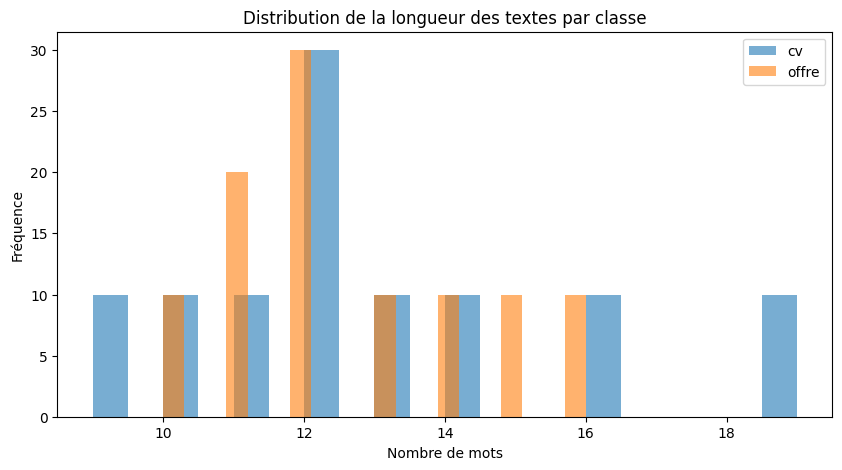

Statistiques de longueur par classe:
       count  mean       std   min   25%   50%   75%   max
label                                                     
cv     100.0  12.8  2.799711   9.0  11.0  12.0  14.0  19.0
offre  100.0  12.6  1.809068  10.0  11.0  12.0  14.0  16.0


In [ ]:
import matplotlib.pyplot as plt

# Distribution de la longueur des textes
df["longueur"] = df["texte_clean"].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
for label in df["label"].unique():
    subset = df[df["label"] == label]
    plt.hist(subset["longueur"], alpha=0.6, label=label, bins=20)

plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")
plt.title("Distribution de la longueur des textes par classe")
plt.legend()
plt.show()

print("Statistiques de longueur par classe:")
print(df.groupby("label")["longueur"].describe())

## Partie 2 : Vectorisation avec TensorFlow

In [ ]:
from sklearn.model_selection import train_test_split

# Séparer X et y
X = df["texte_clean"].values
y = df["label"].values

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Taille train: {len(X_train)}")
print(f"Taille test: {len(X_test)}")

Taille train: 160
Taille test: 40


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Paramètres
max_words = 5000
max_len = 50

# Tokenisation
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Conversion en séquences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
X_train_pad = pad_sequences(
    X_train_seq, maxlen=max_len, padding="post", truncating="post"
)
X_test_pad = pad_sequences(
    X_test_seq, maxlen=max_len, padding="post", truncating="post"
)

print(f"Shape X_train_pad: {X_train_pad.shape}")
print(f"Shape X_test_pad: {X_test_pad.shape}")
print(f"\nVocabulaire: {len(tokenizer.word_index)} mots uniques")

Shape X_train_pad: (160, 50)
Shape X_test_pad: (40, 50)

Vocabulaire: 173 mots uniques


In [8]:
from sklearn.preprocessing import LabelEncoder

# Encodage des labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(f"Classes: {label_encoder.classes_}")
print(f"y_train_encoded: {y_train_encoded[:10]}")

Classes: ['cv' 'offre']
y_train_encoded: [0 1 0 1 1 1 0 0 0 0]


## Partie 3 : Entraînement des Modèles

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

### Modèle 1 : Dense Simple

In [ ]:
embedding_dim = 128

model_dense = keras.Sequential(
    [
        layers.Embedding(max_words, embedding_dim, input_length=max_len),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="Model_Dense",
)

model_dense.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

model_dense.summary()

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Model_Dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_dense = model_dense.fit(
    X_train_pad,
    y_train_encoded,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5781 - loss: 0.6839 - val_accuracy: 1.0000 - val_loss: 0.6418
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6641 - loss: 0.6486 - val_accuracy: 1.0000 - val_loss: 0.5857
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7969 - loss: 0.5761 - val_accuracy: 1.0000 - val_loss: 0.4785
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9219 - loss: 0.4816 - val_accuracy: 1.0000 - val_loss: 0.3721
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9922 - loss: 0.3488 - val_accuracy: 1.0000 - val_loss: 0.2331
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9922 - loss: 0.2388 - val_accuracy: 1.0000 - val_loss: 0.1197
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.1485 - val_accuracy: 1.0000 - val_loss: 0.0516
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9922 - loss: 0.1107 - val_accuracy: 1.0000 - val_loss: 0.0204


### Modèle 2 : GlobalAveragePooling1D

In [ ]:
model_gap = keras.Sequential(
    [
        layers.Embedding(max_words, embedding_dim, input_length=max_len),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="Model_GAP",
)

model_gap.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

model_gap.summary()

Model: "Model_GAP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_gap = model_gap.fit(
    X_train_pad,
    y_train_encoded,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.4922 - loss: 0.6958 - val_accuracy: 0.3750 - val_loss: 0.7017
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5312 - loss: 0.6889 - val_accuracy: 0.3750 - val_loss: 0.6997
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5469 - loss: 0.6876 - val_accuracy: 0.3750 - val_loss: 0.6996
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5391 - loss: 0.6863 - val_accuracy: 0.3750 - val_loss: 0.6952
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5703 - loss: 0.6759 - val_accuracy: 0.3750 - val_loss: 0.6949
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5859 - loss: 0.6777 - val_accuracy: 0.3750 - val_loss: 0.6922
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5938 - loss: 0.6728 - val_accuracy: 0.3750 - val_loss: 0.6832
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6797 - loss: 0.6669 - val_accuracy: 0.4688 - val_loss: 0.6726


### Modèle 3 : CNN

In [ ]:
model_cnn = keras.Sequential(
    [
        layers.Embedding(max_words, embedding_dim, input_length=max_len),
        layers.Conv1D(128, 5, activation="relu"),
        layers.GlobalMaxPooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="Model_CNN",
)

model_cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

model_cnn.summary()

Model: "Model_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_cnn = model_cnn.fit(
    X_train_pad,
    y_train_encoded,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5078 - loss: 0.6770 - val_accuracy: 0.5625 - val_loss: 0.6469
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8750 - loss: 0.5927 - val_accuracy: 1.0000 - val_loss: 0.5692
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9844 - loss: 0.5184 - val_accuracy: 1.0000 - val_loss: 0.4906
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.4337 - val_accuracy: 1.0000 - val_loss: 0.4061
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.3481 - val_accuracy: 1.0000 - val_loss: 0.3140
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9922 - loss: 0.2605 - val_accuracy: 1.0000 - val_loss: 0.2268
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.1840 - val_accuracy: 1.0000 - val_loss: 0.1494
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.1276 - val_accuracy: 1.0000 - val_loss: 0.0894


### Modèle 4 : LSTM

In [ ]:
model_lstm = keras.Sequential(
    [
        layers.Embedding(max_words, embedding_dim, input_length=max_len),
        layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="Model_LSTM",
)

model_lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

model_lstm.summary()

Model: "Model_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train_encoded,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.4609 - loss: 0.6941 - val_accuracy: 0.3750 - val_loss: 0.6961
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5391 - loss: 0.6927 - val_accuracy: 0.3750 - val_loss: 0.7008
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5312 - loss: 0.6920 - val_accuracy: 0.3750 - val_loss: 0.7035
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5312 - loss: 0.6925 - val_accuracy: 0.3750 - val_loss: 0.7066
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5312 - loss: 0.6916 - val_accuracy: 0.3750 - val_loss: 0.7081
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5312 - loss: 0.6906 - val_accuracy: 0.3750 - val_loss: 0.7100
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5312 - loss: 0.6907 - val_accuracy: 0.3750 - val_loss: 0.7139
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5312 - loss: 0.6927 - val_accuracy: 0.3750 - val_loss: 0.7165

### Modèle 5 : Bidirectional LSTM

In [ ]:
model_bilstm = keras.Sequential(
    [
        layers.Embedding(max_words, embedding_dim, input_length=max_len),
        layers.Bidirectional(layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="Model_BiLSTM",
)

model_bilstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

model_bilstm.summary()

Model: "Model_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_bilstm = model_bilstm.fit(
    X_train_pad,
    y_train_encoded,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - accuracy: 0.5312 - loss: 0.6902 - val_accuracy: 0.3750 - val_loss: 0.6934
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5391 - loss: 0.6729 - val_accuracy: 0.6250 - val_loss: 0.6643
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8984 - loss: 0.6355 - val_accuracy: 1.0000 - val_loss: 0.6036
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 1.0000 - loss: 0.5676 - val_accuracy: 1.0000 - val_loss: 0.5057
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.4470 - val_accuracy: 1.0000 - val_loss: 0.3369
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9922 - loss: 0.2769 - val_accuracy: 1.0000 - val_loss: 0.1447
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.1190 - val_accuracy: 1.0000 - val_loss: 0.0499
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.0399 - val_accuracy: 1.0000 - val_loss: 0.0155

## Partie 4 : Évaluation et Comparaison

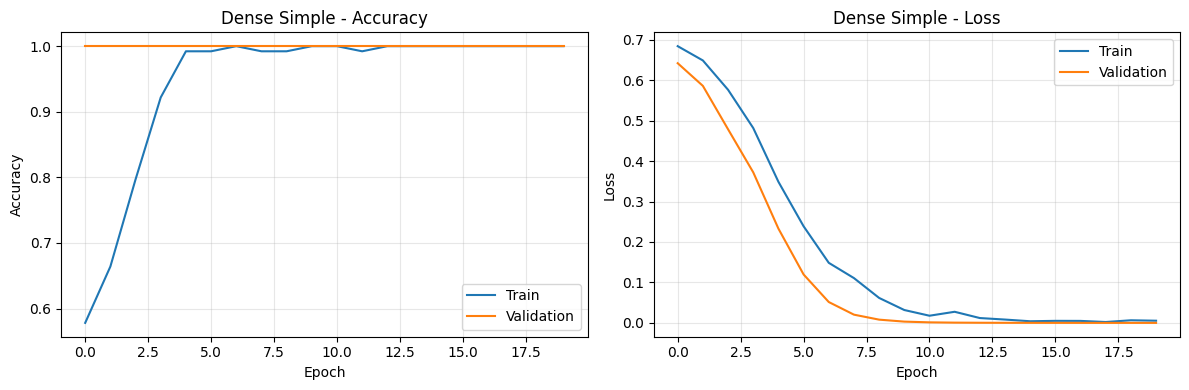

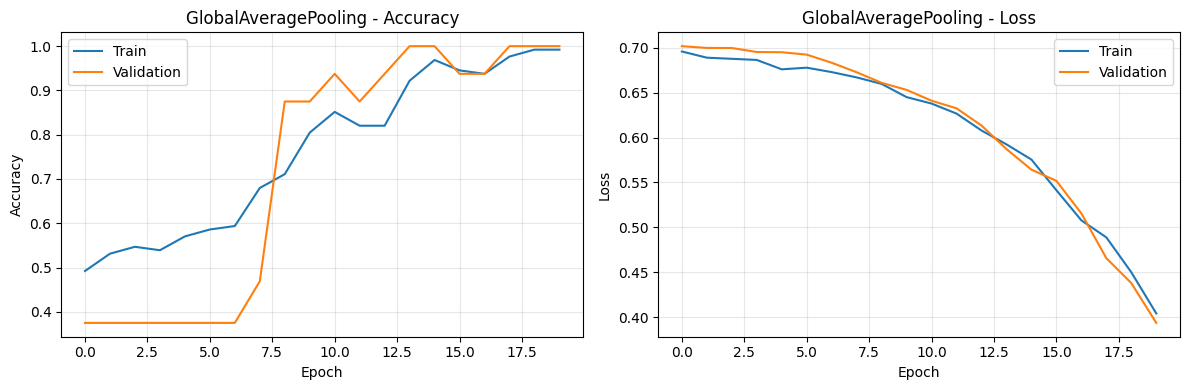

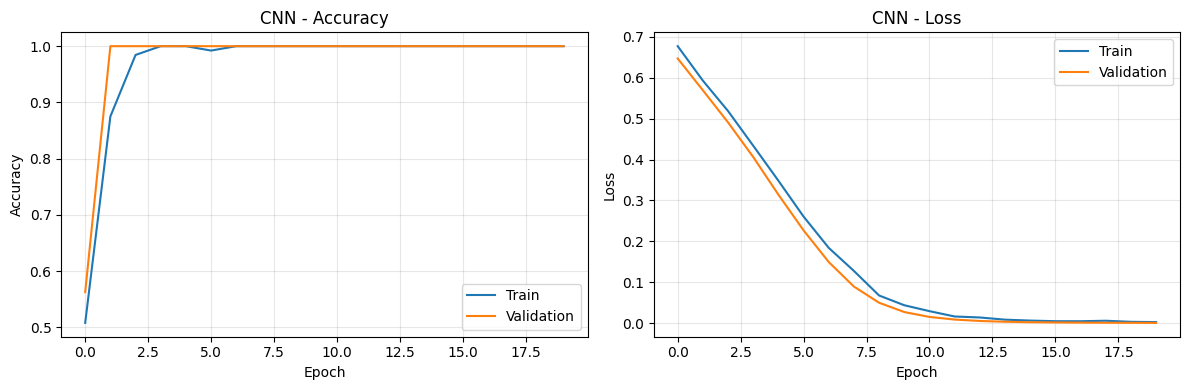

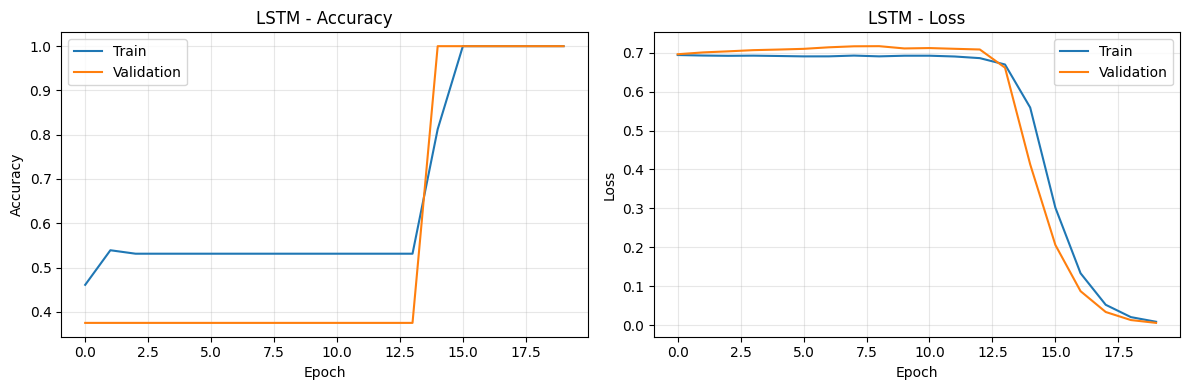

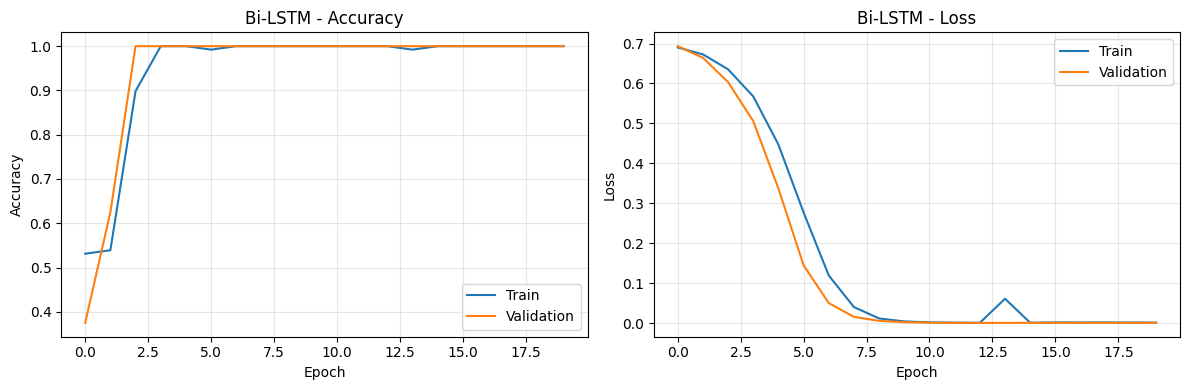

In [ ]:
# Fonction pour visualiser les courbes d'apprentissage
def plot_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy
    ax1.plot(history.history["accuracy"], label="Train")
    ax1.plot(history.history["val_accuracy"], label="Validation")
    ax1.set_title(f"{model_name} - Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss
    ax2.plot(history.history["loss"], label="Train")
    ax2.plot(history.history["val_loss"], label="Validation")
    ax2.set_title(f"{model_name} - Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Visualiser pour chaque modèle
plot_history(history_dense, "Dense Simple")
plot_history(history_gap, "GlobalAveragePooling")
plot_history(history_cnn, "CNN")
plot_history(history_lstm, "LSTM")
plot_history(history_bilstm, "Bi-LSTM")

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


# Fonction pour évaluer un modèle
def evaluate_model(model, X_test, y_test, model_name):
    print(f"\n{'=' * 60}")
    print(f"Évaluation du modèle: {model_name}")
    print(f"{'=' * 60}")

    # Prédictions
    y_pred_proba = model.predict(X_test)
    y_pred = (y_pred_proba > 0.5).astype(int)

    # Métriques
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"\nAUC: {auc:.4f}")

    return y_pred_proba, y_pred, auc


# Évaluer tous les modèles
models = [
    (model_dense, "Dense Simple"),
    (model_gap, "GlobalAveragePooling"),
    (model_cnn, "CNN"),
    (model_lstm, "LSTM"),
    (model_bilstm, "Bi-LSTM"),
]

results = {}
for model, name in models:
    _, _, auc = evaluate_model(model, X_test_pad, y_test_encoded, name)
    results[name] = auc


Évaluation du modèle: Dense Simple
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

Classification Report:
              precision    recall  f1-score   support

          cv       1.00      1.00      1.00        20
       offre       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40


Confusion Matrix:
[[20  0]
 [ 0 20]]

AUC: 1.0000

Évaluation du modèle: GlobalAveragePooling
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

Classification Report:
              precision    recall  f1-score   support

          cv       1.00      1.00      1.00        20
       offre       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40


Confusion Matrix:
[[20  0]
 [ 0 20]]

AUC: 1.0000

Évaluation du modèle: CNN
1/2 ━━━━━━━━━

In [ ]:
# Résumé des performances
print("\n" + "=" * 60)
print("RÉSUMÉ DES PERFORMANCES")
print("=" * 60)
for name, auc in results.items():
    print(f"{name:25s} | AUC: {auc:.4f}")

best_model_name = max(results, key=results.get)
print(f"\nMeilleur modèle: {best_model_name}")


RÉSUMÉ DES PERFORMANCES
Dense Simple              | AUC: 1.0000
GlobalAveragePooling      | AUC: 1.0000
CNN                       | AUC: 1.0000
LSTM                      | AUC: 1.0000
Bi-LSTM                   | AUC: 1.0000

Meilleur modèle: Dense Simple


## Partie 5 : Prédiction sur de Nouveaux Textes

In [ ]:
# Nouveaux textes à prédire
nouveaux_textes = [
    "Startup recherche développeur full-stack, stack moderne, equity offerte.",
    "Ingénieur machine learning, 5 ans d'expérience, spécialiste NLP et computer vision.",
    "Offre : consultant SAP, missions longues durées, clientèle grands comptes.",
    "Designer UI/UX freelance, portfolio riche, recherche CDI dans une scale-up.",
]

# Utiliser le meilleur modèle
best_model = [m for m, n in models if n == best_model_name][0]

# Prétraitement
nouveaux_textes_clean = [nettoyer_texte(t) for t in nouveaux_textes]
nouveaux_seq = tokenizer.texts_to_sequences(nouveaux_textes_clean)
nouveaux_pad = pad_sequences(
    nouveaux_seq, maxlen=max_len, padding="post", truncating="post"
)

# Prédictions
predictions = best_model.predict(nouveaux_pad)
predictions_classes = (predictions > 0.5).astype(int)

# Affichage
print(f"Prédictions avec le modèle: {best_model_name}\n")
for i, texte in enumerate(nouveaux_textes):
    classe = label_encoder.inverse_transform(predictions_classes[i])[0]
    proba = predictions[i][0]
    print(f"Texte: {texte}")
    print(f"Prédiction: {classe.upper()} (confiance: {proba:.2%})\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Prédictions avec le modèle: Dense Simple

Texte: Startup recherche développeur full-stack, stack moderne, equity offerte.
Prédiction: CV (confiance: 44.54%)

Texte: Ingénieur machine learning, 5 ans d'expérience, spécialiste NLP et computer vision.
Prédiction: CV (confiance: 2.99%)

Texte: Offre : consultant SAP, missions longues durées, clientèle grands comptes.
Prédiction: OFFRE (confiance: 87.28%)

Texte: Designer UI/UX freelance, portfolio riche, recherche CDI dans une scale-up.
Prédiction: CV (confiance: 48.19%)

